In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import importlib

# Funciones auxiliares
import auxfun
importlib.reload(auxfun)

<module 'auxfun' from 'c:\\Users\\Deportivo Estadio\\Desktop\\Master Quant\\Gestión de activos\\Trabajo gestión cuantitativa\\Trabajo_gestion_cuantitativa\\Trabajo_gestion_cuantitativa\\Monitoring\\auxfun.py'>

In [7]:
df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
cash = auxfun.calcular_cash_diario(df)
todas_fechas = pd.date_range(start=df['fecha'].min(), end=pd.Timestamp.today(), freq="D")
stoxx_data = yf.download("^STOXX50E", start=todas_fechas.min(), end=todas_fechas.max(), auto_adjust=True, progress=False)["Close"].squeeze()
stoxx_data = stoxx_data.reindex(todas_fechas).ffill()
serie_con_costes = auxfun.valor_cartera_diario(df).reindex(todas_fechas).ffill()
serie_sin_costes = auxfun.valor_cartera_diario(df, incluir_costes=False).reindex(todas_fechas).ffill()

# Normalizamos a 10 millones para comparar con la cartera
stoxx_norm = stoxx_data / stoxx_data.iloc[0] * 10*1e6

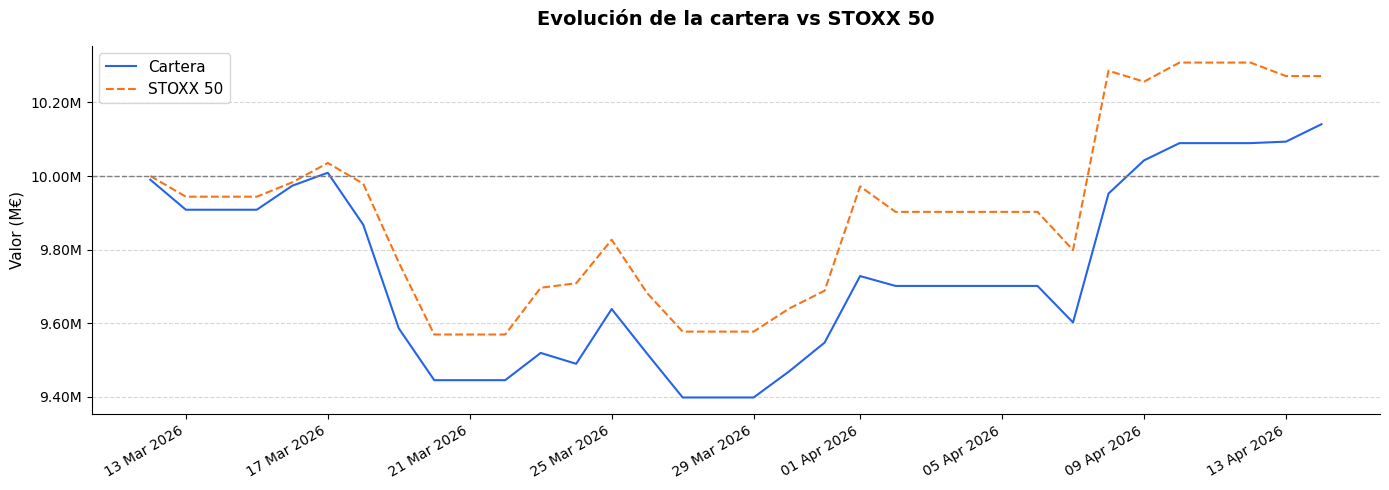

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 5))

df_plot = pd.DataFrame({
    "Cartera": serie_con_costes / 1e6,
    # "Cartera sin costes": serie_sin_costes / 1e6,
    "STOXX50": stoxx_norm / 1e6
})

ax.plot(df_plot.index, df_plot["Cartera"], label="Cartera", color="#2563EB", linewidth=1.5)
ax.plot(df_plot.index, df_plot["STOXX50"], label="STOXX 50", color="#F97316", linewidth=1.5, linestyle="--")
ax.axhline(y=10, color="gray", linestyle="--", linewidth=1)

ax.set_title("Evolución de la cartera vs STOXX 50", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Valor (M€)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}M"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b %Y"))
plt.xticks(rotation=30, ha="right")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
import sys
sys.path.append("../")  # o la ruta donde esté auxiliary_functions.py
from auxiliary_functions import build_metrics_table

metrics = build_metrics_table({
    "Cartera": serie_con_costes,
    # "Cartera sin costes": serie_sin_costes,
    "STOXX50": stoxx_norm
}, periods_per_year=365)  # usamos 365 porque la serie es diaria con todos los días del calendario

display(metrics.T)

,Cartera,STOXX50
Rentabilidad total,0.015089,0.027158
Rentabilidad anualizada,0.180151,0.344982
Volatilidad anualizada,0.214339,0.243664
Sharpe,0.876522,1.333214
Sortino,1.357190,2.575337
Max Drawdown,-0.061015,-0.046448
Calmar,2.952568,7.427260
Win rate,0.363636,0.303030
Mejor periodo,0.036479,0.049732
Peor periodo,-0.028519,-0.021444


In [10]:
df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
tabla = auxfun.rentabilidad_semanal_por_periodo(df)
display(tabla.style.format("{:.2%}"))

,Ret. Cartera,Ret. STOXX50,Alpha
Periodo,,,
2026-03-12 → 2026-03-20,-5.43%,-4.31%,-1.13%
2026-03-20 → 2026-03-27,-0.44%,0.08%,-0.52%
2026-03-27 → 2026-04-03,3.22%,3.40%,-0.17%
2026-04-03 → 2026-04-10,4.05%,4.10%,-0.05%
